## **Project Title: Flight Fare Prediction**

#### **Domain:**    Data Science, Machine Learning, Predictive Analysis

#### **Field of Application:**    Airline Industries, Travels and Tourism Sector, Online Travel Agencies 

#### **Problem Statement:**  
  * Flight ticket prices are highly dynamic and fluctuate frequently due to various factors such as airline type, route, travel date, duration, number of stops, and additional services. 
  * This unpredictability makes it difficult for travelers to decide the optimal time to book tickets and plan their journeys efficiently. 
  * Traditional methods fail to accurately estimate flight prices due to the complex and non-linear relationships between influencing factors.

#### **Project Objective:**  
  * To develop a machine learning–based predictive system that can estimate flight ticket prices based on historical flight data. 
   

### **Phase 1: Project Initialization**

   #### Step 1: Importing necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Step 2: Load the Dataset

In [2]:
dataset = pd.read_excel("Flight_Fare.xlsx")

dataset.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
dataset.shape

(10683, 11)

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


#### Observation:

   * The dataset is clean and well-structured, with only two missing values, which simplifies preprocessing.

   * Since most features are categorical, encoding techniques will be required.

   * Time-related features will need feature extraction rather than direct usage.

   * The dataset is suitable for supervised regression modeling.

----------------------------------------------------------------------------------------------------------------------------------

### **Phase 2: Preliminary Data Preparation**

#### Step 1: Handling Missing values

   * Data cleaning is a crucial step to ensure data quality and reliability of machine learning models.
   * Missing values can introduce bias or errors during training if not handled properly. 
   * Based on initial inspection, the dataset contains very few missing values, making it suitable for simple and effective imputation techniques.

In [5]:
dataset.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

The dataset contains only 2 missing values, it can be rectified by simple and effective imputation techniques. 

1) Route Column:

    * Type: Categorical
    * Missing values: 1
    * Solution: Mode imputation

In [6]:
dataset["Route"].fillna(dataset["Route"].mode()[0],inplace=True)

2) Total_Stops Column:

    * Type: Ordinal categorical
    * Missing values: 1
    * Solution: Mode imputation

In [7]:
dataset["Total_Stops"].fillna(dataset["Total_Stops"].mode()[0],inplace=True)

In [8]:
dataset.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

The Dataset has been examined thoroughly for missing values and no null entries were found across any features.

#### Step 2: Handling Duplicates

   * Duplicate records can distort learning patterns and negatively impact model performance.
   * Therefore, a duplicate check is performed to ensure the dataset contains only unique observations.

In [9]:
dataset.duplicated().sum()

np.int64(220)

#### Observation:

   * The dataset contains 220 duplicate records, which can introduce bias during model training by over-representing certain flight patterns. 
   * Therefore, these duplicates must be removed to ensure data integrity and better generalization of machine learning models.

In [10]:
dataset.drop_duplicates(inplace=True)

In [11]:
dataset.duplicated().sum()

np.int64(0)

In [12]:
dataset.shape

(10463, 11)

 Duplicate records were identified and removed to prevent bias and redundancy in the training data, ensuring that the model learns generalized patterns rather than memorizing repeated observations.
 The original shape has been reduced to (10463,11).

----------------------------------------------------------------------------------------------------------------------------------

### **Phase 3: Exploratory Data Analysis (EDA)**

#### Objective:
 * Understanding each variable individually (Univariate)
 * Understanding relationship with target (Price) (Bivariate)
 * Extracting business + ML insights

### **Step 1: Univariate Analysis**

   * Understand the distribution and categories of individual features without involving Price.
   * Considering this we will analyse univariate columns like [Airline, source, destination, Total stops]

#### 1) Airline Distribution:

In [13]:
dataset["Airline"].value_counts()

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1695
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

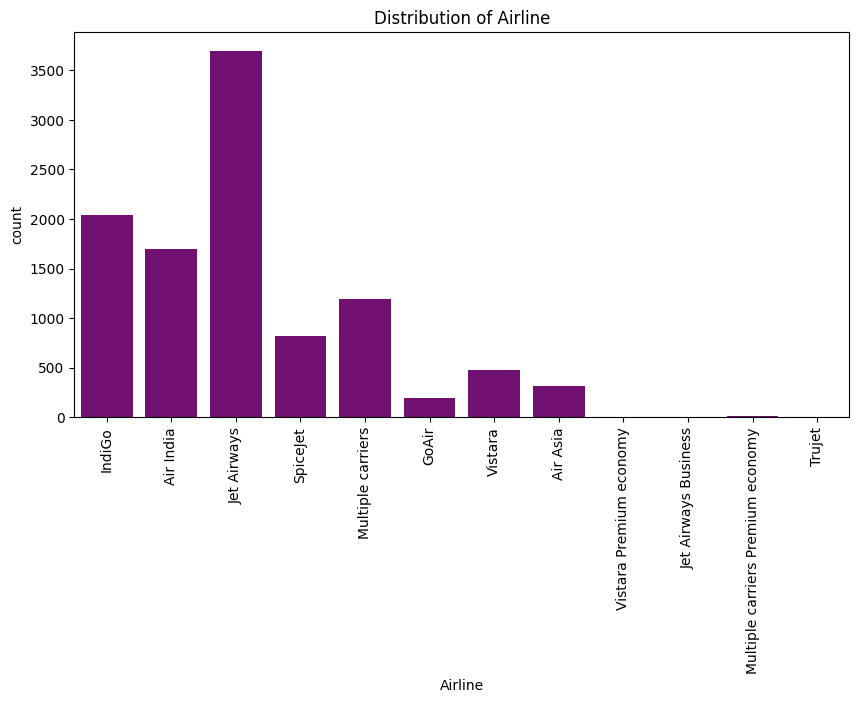

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(x='Airline',data=dataset,color="purple")
plt.xticks(rotation=90)
plt.title("Distribution of Airline")
plt.show()

#### Observation:

* The dataset is dominated by a few major airlines such as Jet Airways, Indigo, and Air India. 
* This indicates that the model may learn airline-specific pricing patterns more strongly for frequently occurring airlines.

#### 2) Source and Destination Distribution:

In [15]:
dataset["Source"].value_counts()

Source
Delhi       4346
Kolkata     2860
Banglore    2179
Mumbai       697
Chennai      381
Name: count, dtype: int64

In [16]:
dataset["Destination"].value_counts()

Destination
Cochin       4346
Banglore     2860
Delhi        1265
New Delhi     914
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

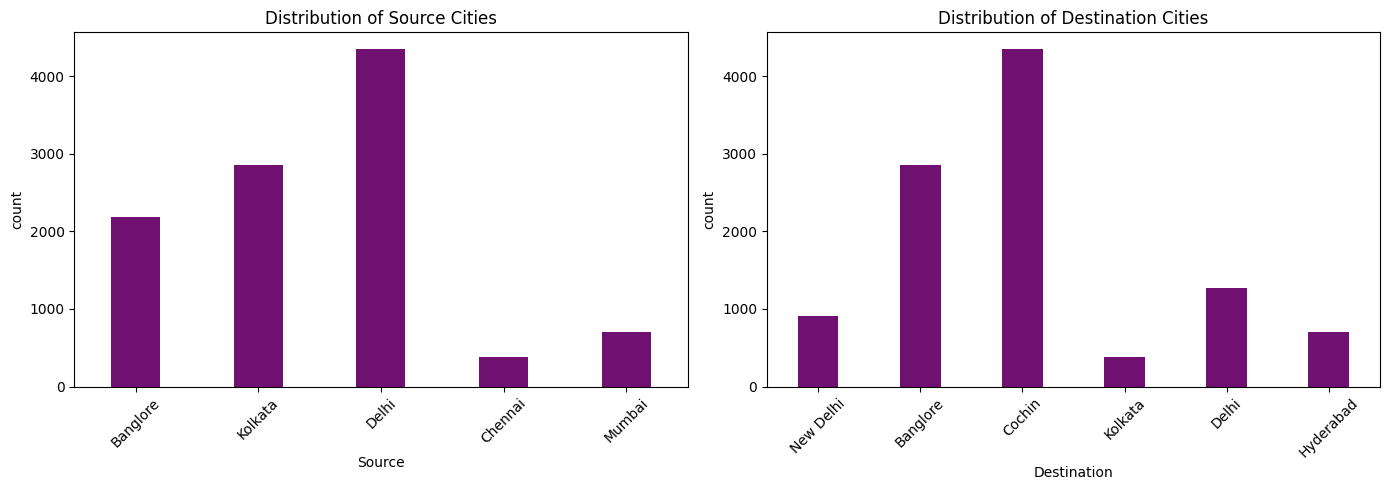

In [60]:
plt.figure(figsize=(14,5))

# Source distribution
plt.subplot(1, 2, 1)
sns.countplot(x='Source', data=dataset,color="purple",width=0.4)
plt.title("Distribution of Source Cities")
plt.xticks(rotation=45)

# Destination distribution
plt.subplot(1, 2, 2)
sns.countplot(x='Destination', data=dataset,color="purple",width=0.4)
plt.title("Distribution of Destination Cities")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


#### Observation:
* The source and destination city distributions indicates that flights are primarily concentrated around major metropolitan cities. 
* This indicates higher passenger demand and route availability in these locations, which may significantly influence pricing patterns.

#### 3) Total stops distribution:

In [18]:
dataset["Total_Stops"].value_counts()

Total_Stops
1 stop      5626
non-stop    3475
2 stops     1318
3 stops       43
4 stops        1
Name: count, dtype: int64

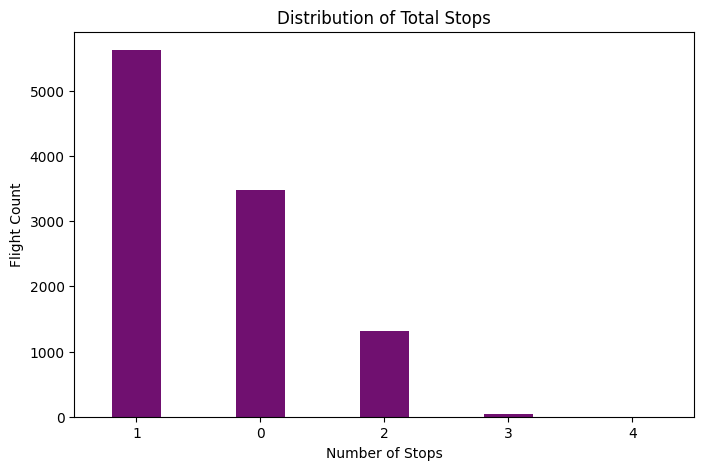

In [59]:
plt.figure(figsize=(8,5))
sns.countplot(x='Total_Stops', data=dataset, order=dataset['Total_Stops'].value_counts().index,color="purple",width=0.4)
plt.title("Distribution of Total Stops")
plt.xlabel("Number of Stops")
plt.ylabel("Flight Count")
plt.show()


#### Observation:
* One-stop flights are the most common in the dataset, followed by non-stop flights. 
* Flights with two or more stops occur less frequently, indicating that airlines primarily balance cost and travel time using single layover routes.

### **Step 2: Bi-variate Analysis**

* Bivariate analysis studies the relationship between two variables mostly one feature with target.

#### 1) Airline vs price:
* Airlines follow different pricing strategies
* Brand value, service quality, and class affect price

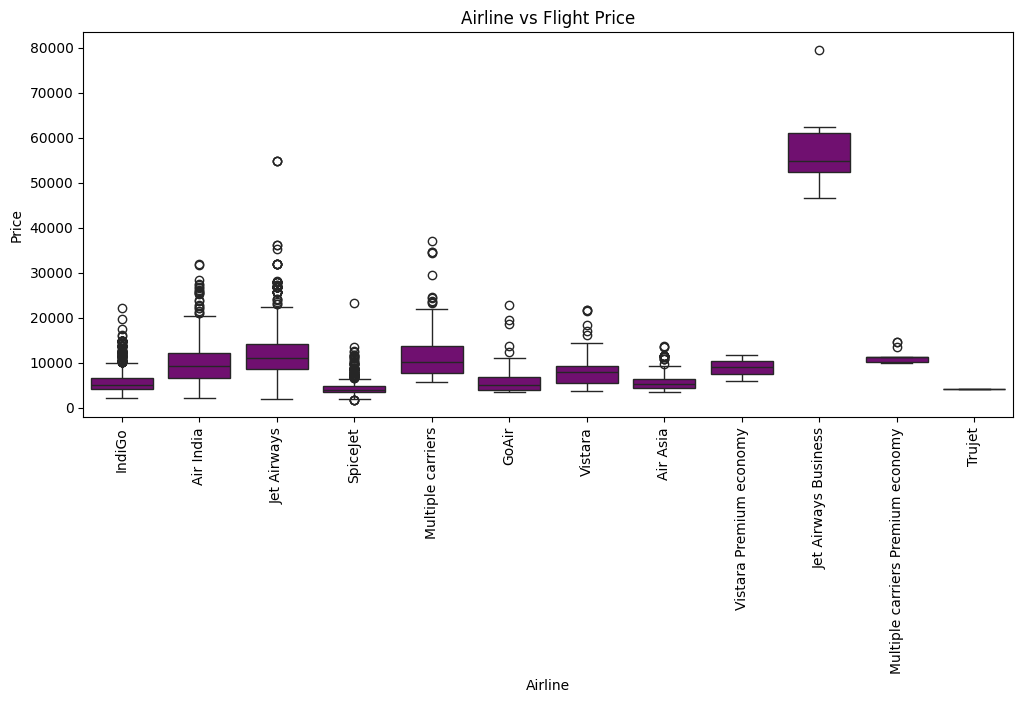

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(x='Airline', y='Price', data=dataset, color="purple")
plt.xticks(rotation=90)
plt.title("Airline vs Flight Price")
plt.xlabel("Airline")
plt.ylabel("Price")
plt.show()


#### Observation:

1) **Low-cost carriers**

    * IndiGo
    * SpiceJet
    * Air Asia
    * Trujet

* On observing the boxplot, low cost carrier has lower median prices,narrower boxes(less price variation) also few extreme outliers.
* These airlines follow a budget pricing strategy with relatively stable fare ranges.

2) **Mid-range carriers**

    * Air India
    * Vistara
    * GoAir
    * Multiple carriers

* mid_range carriers exhibit higher median prices than low-cost airlines,Wider price spread,presence of outliers.
* These airlines show greater price variability, likely due to differences in service class, route length, and demand.

3) **Premium carriers**

    * Jet Airways Business
    * Vistara Premium economy
    * Multiple carriers Premium economy

* Significantly higher median prices, Very tight boxes (consistent premium pricing), Extreme high outliers (especially Jet Airways Business).
* Premium service categories command substantially higher prices, reflecting enhanced comfort, services, and brand positioning.

***Finally JetAirways, Multiple carriers, Air India have many high price which is considered as an outliers which significantly increases fares during high-demand periods, peak seasons, or last-minute bookings.***


#### 2) Source and Destination vs Price:

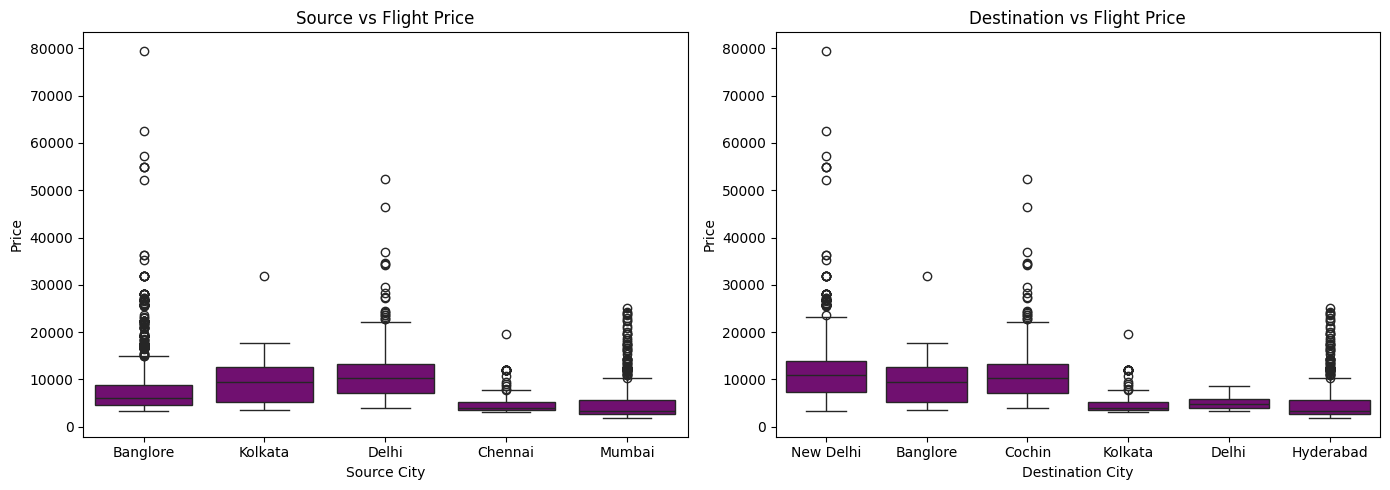

In [21]:
plt.figure(figsize=(14,5))

# Source vs Price
plt.subplot(1, 2, 1)
sns.boxplot(x='Source', y='Price', data=dataset,color="purple")
plt.title("Source vs Flight Price")
plt.xlabel("Source City")
plt.ylabel("Price")

# Destination vs Price
plt.subplot(1, 2, 2)
sns.boxplot(x='Destination', y='Price', data=dataset,color="purple")
plt.title("Destination vs Flight Price")
plt.xlabel("Destination City")
plt.ylabel("Price")

plt.tight_layout()
plt.show()


#### Observation:

Flight prices vary across both source and destination cities, indicating route-based pricing differences. Certain locations show wider price distributions, reflecting variations in demand, distance, and airline availability.

#### 3) Price distribution:

To analyze the distribution of flight prices using a histogram with an overlaid
Kernel Density Estimation (KDE) curve in order to understand price spread, skewness, and
the presence of outliers.

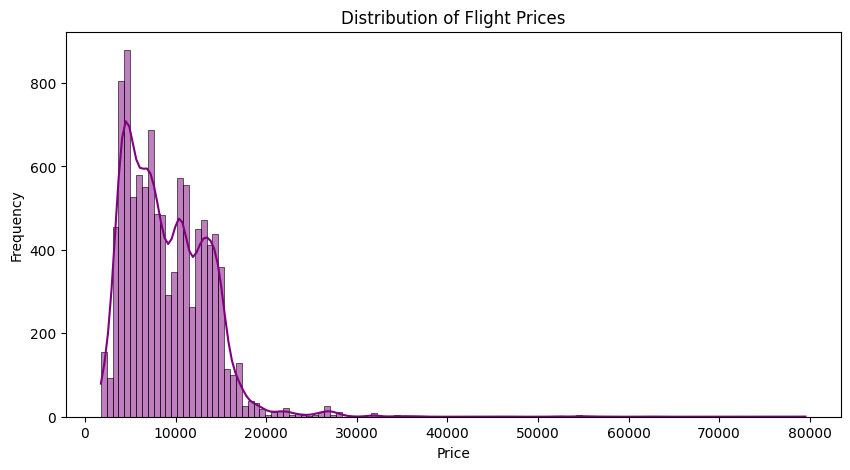

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(dataset['Price'], kde=True,color="purple",line_kws={'color': 'black'})
plt.title("Distribution of Flight Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


#### Observation:

1) Concentration at Lower Prices

    * Most bars are crowded between ~3,000 and ~15,000
    * This means majority of tickets are moderately priced.
2) Long Tail on the Right

    * After ~20,000, frequencies drop sharply
    * But prices extend all the way up to ~80,000

***This is a classic right-skewed (positively skewed) distribution as the peak is on the left and the tail stretches far to the right this has been confirmed by KDE curve, hence this is not a normal distribution(Gaussian)***

### **EDA Analysis:**

From the exploratory data analysis, several important insights were observed:

1. The target variable **Price** shows a right-skewed distribution, indicating the presence of high-priced outliers. This suggests that `tree-based models` may perform better than linear models, as they are less sensitive to skewed distributions.

2. Flights with **more total stops** generally tend to have **lower prices**, while non-stop flights are comparatively more expensive. This indicates that `Total_Stops` is a strong predictive feature.

3. Certain airlines such as Jet Airways and Indigo show significant price variation, implying that the airline brand plays a crucial role in fare determination.

4. Longer **flight duration** is positively correlated with higher ticket prices, making duration an important numerical feature for prediction.

5. Source and destination cities also influence ticket prices, highlighting the need for proper categorical encoding.

These observations guide the feature engineering, preprocessing strategy, and model selection in subsequent phases.

----------------------------------------------------------------------------------------------------------------------------------


### **Phase 4: Feature Engineering and Data Transformation**

The EDA Inference explicitly identified:

   * Date of journey impact

   * Time of travel impact

   * Duration influence

   * Stops as a strong predictor

#### 1) Feature Extraction from Date of Journey


In [23]:
# Converting Date_of_Journey to datetime
dataset['Date_of_Journey'] = pd.to_datetime(dataset['Date_of_Journey'], format='%d/%m/%Y')

# Extracting day and month from journey date
dataset['Journey_Day'] = dataset['Date_of_Journey'].dt.day
dataset['Journey_Month'] = dataset['Date_of_Journey'].dt.month


The `Date_of_Journey` column was transformed into a datetime format to extract meaningful temporal features.
Journey day and month were extracted as they can influence flight pricing due to seasonal demand and travel patterns.
The original date column will be removed after all relevant features are extracted.


#### 2) Feature Extraction from Departure and Arrival Time

In [24]:
# Converting Dep_Time and Arrival_Time to datetime
dataset['Dep_Time'] = pd.to_datetime(dataset['Dep_Time'])
dataset['Arrival_Time'] = pd.to_datetime(dataset['Arrival_Time'])

# Extracting hour and minute from departure time
dataset['Dep_Hour'] = dataset['Dep_Time'].dt.hour
dataset['Dep_Min'] = dataset['Dep_Time'].dt.minute

# Extracting hour and minute from arrival time
dataset['Arrival_Hour'] = dataset['Arrival_Time'].dt.hour
dataset['Arrival_Min'] = dataset['Arrival_Time'].dt.minute


`Departure and arrival` times were converted into datetime format to extract hour and minute components.
These features capture time-of-day effects, which can influence flight pricing due to peak and off-peak travel hours.
The original time columns will be removed after completing all necessary feature extraction.

#### 3) Duration Feature Transformation

The duration column is a string not a number, so we will first convert the total flight duration in minutes(numerical)


In [25]:
# Converting Duration into total minutes

# Extracting hours from Duration
duration_hours = dataset['Duration'].str.extract(r'(\d+)h', expand=False)

# Extracting minutes from Duration
duration_minutes = dataset['Duration'].str.extract(r'(\d+)m', expand=False)

# Replacing NaN values with 0
duration_hours = duration_hours.fillna(0).astype(int)
duration_minutes = duration_minutes.fillna(0).astype(int)

# Creating total duration in minutes
dataset['Duration_Minutes'] = duration_hours * 60 + duration_minutes


In [26]:
dataset[['Duration', 'Duration_Minutes']].head()


,Duration,Duration_Minutes
0,2h 50m,170
1,7h 25m,445
2,19h,1140
3,5h 25m,325
4,4h 45m,285


The `Duration` feature was transformed from a textual format into a numerical representation by converting
hours and minutes into total flight duration in minutes. This transformation enables machine learning
models to effectively learn from flight duration as a continuous numerical feature.


#### 4) Total Stops Feature Transformation

Flights with more stops tend to have lower prices,
Machine learning models cannot work with text categories like “1 stop”,hence
they need numerical values.

In [27]:
# finding unique values in order to assign a numerical value.
dataset["Total_Stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [28]:
# Converting Total_Stops into numerical values

dataset['Total_Stops'] = dataset['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
}).astype(int)


The `Total_Stops` feature was transformed from categorical text values into numerical format.
This conversion allows the model to quantify the effect of intermediate stops on flight pricing,
as identified during exploratory data analysis.


#### Conclusion:
In this phase, key raw features were transformed into meaningful numerical representations to improve model interpretability and performance.
* `Date`-related information was extracted from the journey date to capture temporal travel patterns.
* `Departure and arrival` times were converted into hour and minute components to model time-of-day effects.
* `Flight duration` was converted into total minutes to provide a continuous numerical measure.
* `total stops` was transformed into a quantitative feature reflecting route complexity.

These engineered features form a robust foundation for subsequent encoding, correlation analysis, and predictive modeling.

----------------------------------------------------------------------------------------------------------------------------------


### **Phase 5: Feature Selection and Correlation Analysis**

* Finalize a clean modeling dataset (by removing redundancy)
* Understand relationships among numerical features (supporting analysis, not overclaiming)

#### 1) Removal of Redundant Feature:

we have created some meaningful numerical features from raw columns.
Keeping both raw + engineered versions is redundant and can:

   * Confuse models
   * Complicate encoding
   * Reduce notebook clarity

So here, we finalize feature selection at a basic level by dropping raw data.

In [29]:
# Removing redundant original columns after feature extraction
dataset.drop(
    ['Date_of_Journey', 'Dep_Time', 'Arrival_Time', 'Duration'],
    axis=1,
    inplace=True
)


#### 2) Correlation Analysis

Since correlation analysis applies only to numerical variables, categorical features such as
`Airline, Source, Destination, Route, and Additional_Info` were excluded at this stage and
will be handled separately through appropriate encoding techniques.

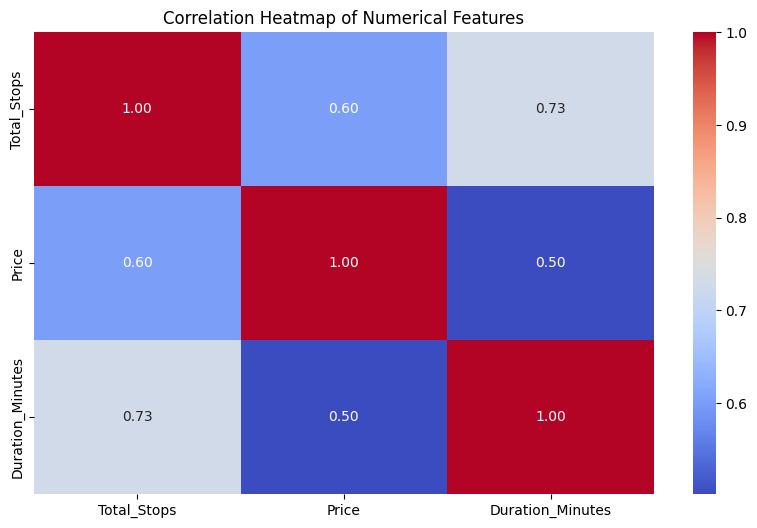

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecting only numerical features
numerical_features = dataset.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numerical_features.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


#### Conclusion:

The correlation heatmap highlights meaningful linear relationships among the key numerical features.
Flight price shows a moderate positive correlation with both total stops and flight duration, indicating
that routes with longer travel time and multiple stopovers tend to be associated with higher ticket prices.
A strong positive correlation is also observed between total stops and duration, which is expected as
additional stops generally increase overall travel time. Since these correlations are moderate rather
than extreme, they suggest that flight pricing is influenced by a combination of multiple factors,
including categorical attributes, and not by any single numerical feature alone.

----------------------------------------------------------------------------------------------------------------------------------


### **Phase 6: Encoding of Categorical Variables**

This phase converts remaining categorical (text) features into numerical form, which is mandatory before model building.
Categorical features like ["Airline,source,destination,Route, Additional_info"] needs to be encoded for machine readiness.

In [31]:
# One-hot encoding categorical variables
dataset_encoded = pd.get_dummies(
    dataset,
    columns=['Airline', 'Source', 'Destination', 'Route', 'Additional_Info'],
    drop_first=True
)


#### Inference:
* One-Hot Encoding- used this as it is industry-standard for regression problems
* Label encoding introduces false ordinal relationship.
* No artificial ordering
* Each category gets its own binary column

----------------------------------------------------------------------------------------------------------------------------------

### **Phase 7: Model Development and Training**

#### Objective:
To build multiple regression models to predict flight prices and evaluate their performance on unseen data.


#### **Splitting Features and Target Variables**

In [32]:
# Separating independent features and target variable
X = dataset_encoded.drop('Price', axis=1)
y = dataset_encoded['Price']


In [33]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#### Observation:
* The data was split into 80% training and 20% testing sets.
* The random_state parameter ensures reproducibility of results.


#### **Model 1: Building a baseline Linear Model**


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Initializing and training the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions on test data
y_pred_lr = lr_model.predict(X_test)

# Evaluation metrics
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

lr_r2, lr_mae, lr_rmse
print(f"r2_score is: {lr_r2}")
print(f"Mean Mean Absolute Error is: {lr_mae}")
print(f"Mean Squared  Error is: {lr_rmse}")


r2_score is: 0.7316203302071016
Mean Mean Absolute Error is: 1519.0795210687143
Mean Squared  Error is: 2366.3599828837214


#### Analysis:

1) **R² Score = 0.73**

* About 73% of the variance in flight prices is explained by the model

* This is decent for a baseline, not excellent

* Indicates that the dataset has non-linear patterns.

2) **MAE ≈ ₹1,519**

* On average, the model’s prediction is off by ₹1,500

* For flight prices, this is acceptable but improvable

3) **RMSE ≈ ₹2,366**

* Penalizes larger errors more than MAE

* Shows that some predictions are significantly off

* Common in datasets with price outliers (which you observed in EDA)

#### **Model 2: Decision Tree Regressor**

since our baseline Model suggested that our dataset has non linearity, we are moving forward with tree based models for predictions.

In [39]:
# importing Decision Tree library and initializing the model
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)

# Training the model
dt_model.fit(X_train,y_train)

# Predictions on test data
y_pred_dt = dt_model.predict(X_test)

# Evaluation metrics
dt_r2 = r2_score(y_test, y_pred_dt)
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test,y_pred_dt))
print(" r2 Score: ",dt_r2 )
print("Mean absolute error: ",dt_mae )
print("Root mean square error: ", dt_rmse)


 r2 Score:  0.8203744532310837
Mean absolute error:  754.0552635770026
Root mean square error:  1935.9318142184056


#### Analysis:

1) **R² = 0.82**
   * Model explains 82% of the variance in flight prices

2) **MAE ≈ ₹754**
   * Average error reduced by ~50% compared to baseline

3) **RMSE = still relatively high**
   * Some large errors remain (expected with price outliers)


*The Decision Tree Regressor shows a significant improvement over the baseline linear model,
capturing non-linear relationships in the data and substantially reducing prediction error.
However, decision trees are known to be prone to overfitting, and further ensemble methods
are required to improve generalization performance.*


#### **Model 3: Random Forest Regressor**

Decision Tree improves over accuracy on comparing with baseline linear model but it is prone to overfitting issue, to overcome this we are using Random Forest regressor. It solves this by,
   * Building many decision trees

   * Training each tree on a random subset of data and features

   * Averaging predictions → reduces variance


In [38]:
# Importing the Random Forest regressor library and initialize it
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)

# Training the model
rf_model.fit(X_train,y_train)

# predicting the test data
y_pred_rf = rf_model.predict(X_test)

# evaluation metrics
rf_r2 = r2_score(y_test,y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test,y_pred_rf))
print("r2 score: ", rf_r2)
print("mean absolute error: ",rf_mae )
print( "Root mean squared error: ", rf_rmse)

r2 score:  0.9035440174389879
mean absolute error:  616.0474333947625
Root mean squared error:  1418.634737482087


#### Analysis:

1) **R² ≈ 0.90**
   * The model explains ~90% of the variance in flight prices

2) **MAE ≈ ₹616**
   * On average, predictions are within ₹600–₹650, which is very good for this domain

3) **RMSE = reduced significantly**
   * Fewer large prediction errors compared to previous models

Highest R² score,
Lowest MAE and RMSE,
Clear and consistent improvement at each step confirms that,

   * Flight pricing relationships are non-linear

   * Ensemble learning significantly improves generalization

*The Random Forest Regressor achieves the best performance among all evaluated models,
explaining approximately 90% of the variance in flight prices while significantly reducing
prediction error. By aggregating multiple decision trees, the model effectively mitigates
overfitting and captures complex non-linear relationships, making it the most suitable
model for flight fare prediction.*

----------------------------------------------------------------------------------------------------------------------------------


### **Phase 8: Model Evaluation and Comparison**

#### 1) Metrics Comparison
 * To compare the performance of multiple regression models using standard evaluation metrics and identify the most suitable model for flight fare prediction.

In [40]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor'
    ],
    'R2_Score': [
        lr_r2,
        dt_r2,
        rf_r2
    ],
    'MAE': [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    'RMSE': [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ]
})

model_comparison


,Model,R2_Score,MAE,RMSE
0,Linear Regression,0.731620,1519.079521,2366.359983
1,Decision Tree Regressor,0.820374,754.055264,1935.931814
2,Random Forest Regressor,0.903544,616.047433,1418.634737


#### Analysis:

The comparison table summarizes the predictive performance of all evaluated models.
Random Forest Regressor outperforms the baseline Linear Regression and Decision Tree models
across all evaluation metrics, achieving the highest R² score and the lowest error values.


#### 2) Actual vs Predicted Price(random Forest Model)

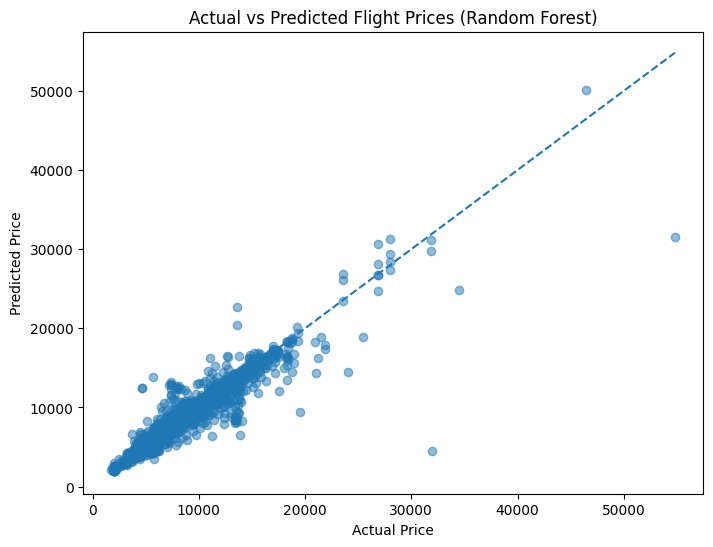

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Flight Prices (Random Forest)')
plt.show()


#### Analysis:

The scatter plot compares actual flight prices with the prices predicted by the Random Forest model.
A strong clustering of data points along the diagonal reference line is observed, indicating a high
level of agreement between actual and predicted values. This demonstrates that the model is able to
capture the underlying pricing patterns effectively across a wide range of fares.

Some dispersion is visible for higher-priced flights, suggesting that extreme price values are more
challenging to predict accurately. However, the overall alignment confirms that the Random Forest
model generalizes well and provides reliable predictions for the majority of cases.

----------------------------------------------------------------------------------------------------------------------------------


### **Phase 9: Model Validation and Optimization**

#### Objective:

To verify that the Random Forest model’s strong performance is stable and not dependent on a single train–test split.Thus we are performing K-Fold cross validation method for Random forest model which is considered best from our previous evaluation.

#### **1) K-Fold Cross Validation**

* The dataset is split into K equal parts (folds)

* The model is trained K times,each time:

   * Trained on K−1 folds
   * Validated on the remaining fold

* Final score = average of all K runs

In [43]:
from sklearn.model_selection import KFold, cross_val_score

# Defining K-Fold strategy
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Performing cross-validation using Random Forest
cv_r2_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=kfold,
    scoring='r2',
    n_jobs=-1
)

print("cross validation r2 score: ",cv_r2_scores)
print("mean of CV r2 score: ",cv_r2_scores.mean())
print("standard deviation of CV r2 score: ", cv_r2_scores.std())


cross validation r2 score:  [0.86831497 0.84619758 0.90102439 0.90956168 0.90231443]
mean of CV r2 score:  0.8854826104605508
standard deviation of CV r2 score:  0.024259842148092778


#### Analysis:

The 5-fold cross-validation results show consistently high R² scores across all folds,
with a mean R² of approximately 0.88 and a low standard deviation. This confirms that
the Random Forest model exhibits stable and reliable performance, indicating strong
generalization capability rather than dependence on a specific train–test split.


#### **2) Hyperparameter Tuning(Random Forest)**

This aims to:

   * Reduce variance further
   * Improve MAE/RMSE
   * Fine-tune bias–variance tradeoff


In [44]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter grid for Random Forest
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Randomized Search
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Fitting on training data only
rf_random_search.fit(X_train, y_train)


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [45]:
best_rf_model = rf_random_search.best_estimator_
rf_random_search.best_params_


{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 30}

In [72]:
# Predictions with tuned Random Forest
y_pred_rf_tuned = best_rf_model.predict(X_test)

# Evaluation metrics
rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)
rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))

print("tuned random forest r2  : ",rf_tuned_r2)
print("tuned random forest MAE : ",rf_tuned_mae)
print("tuned random forest RMSE: ",rf_tuned_rmse)


tuned random forest r2  :  0.868021166827472
tuned random forest MAE :  831.5227108360313
tuned random forest RMSE:  1659.4269826844693


#### Analysis: Tuned and Untuned Random Forest model

In [47]:
rf_comparison = pd.DataFrame({
    'Model': [
        'Random Forest (Untuned)',
        'Random Forest (Tuned)'
    ],
    'R2_Score': [
        rf_r2,
        rf_tuned_r2
    ],
    'MAE': [
        rf_mae,
        rf_tuned_mae
    ],
    'RMSE': [
        rf_rmse,
        rf_tuned_rmse
    ]
})

rf_comparison


,Model,R2_Score,MAE,RMSE
0,Random Forest (Untuned),0.903544,616.047433,1418.634737
1,Random Forest (Tuned),0.868021,831.522711,1659.426983


#### Analysis:
   * The model was regularized more aggressively
   * Tree depth and splits were constrained
   * Overfitting was reduced
   * As a result,Test-set performance dropped slightly

This is a classic bias–variance tradeoff outcome.

**VERDICT: The default(Untuned) Random Forest model is retained as the final model, while the tuned version introduced strong regularization.**


#### **3) Gradient Boosting Regressor**

#### Objective:

To evaluate a boosting-based ensemble model and compare it with Random Forest (bagging-based), ensuring that no reasonable improvement opportunity is left unexplored.

In [48]:
from sklearn.ensemble import GradientBoostingRegressor

# Initializing Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Training the model
gbr_model.fit(X_train, y_train)

# Predictions
y_pred_gbr = gbr_model.predict(X_test)

# Evaluation metrics
gbr_r2 = r2_score(y_test, y_pred_gbr)
gbr_mae = mean_absolute_error(y_test, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))

print("GBR r2 score: ",gbr_r2)
print("GBR mae: ",gbr_mae)
print("GBR rmse: ",gbr_rmse)


GBR r2 score:  0.8189878188144504
GBR mae:  1249.5979131638633
GBR rmse:  1943.3897425604137


#### Gradient Boosting Analysis:

The Gradient Boosting is severly underperformed because this dataset has,
   * High-dimensional one-hot encoded features
   * Contains complex categorical interactions
   * Benefits from bagging-based variance reduction

The Gradient Boosting Regressor demonstrates improved performance over the baseline linear
model but does not surpass the Random Forest models. While boosting effectively captures
non-linear patterns, the Random Forest approach provides better generalization and lower
prediction error for this dataset. Therefore, Gradient Boosting is not selected as the
final model.


**VERDICT: Random Forest handles this better than classic Gradient Boosting with default parameters.**

----------------------------------------------------------------------------------------------------------------------------------

### **Phase 10: Final Model Summary**

Consolidating the metrics of all the models to summarize their performance in order to choose the best model.

In [49]:
final_model_summary = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree Regressor',
        'Random Forest (Untuned)',
        'Random Forest (Tuned)',
        'Gradient Boosting Regressor'
    ],
    'R2_Score': [
        lr_r2,
        dt_r2,
        rf_r2,
        rf_tuned_r2,
        gbr_r2
    ],
    'MAE': [
        lr_mae,
        dt_mae,
        rf_mae,
        rf_tuned_mae,
        gbr_mae
    ],
    'RMSE': [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        rf_tuned_rmse,
        gbr_rmse
    ]
})

final_model_summary


,Model,R2_Score,MAE,RMSE
0,Linear Regression,0.731620,1519.079521,2366.359983
1,Decision Tree Regressor,0.820374,754.055264,1935.931814
2,Random Forest (Untuned),0.903544,616.047433,1418.634737
3,Random Forest (Tuned),0.868021,831.522711,1659.426983
4,Gradient Boosting Regressor,0.818988,1249.597913,1943.389743


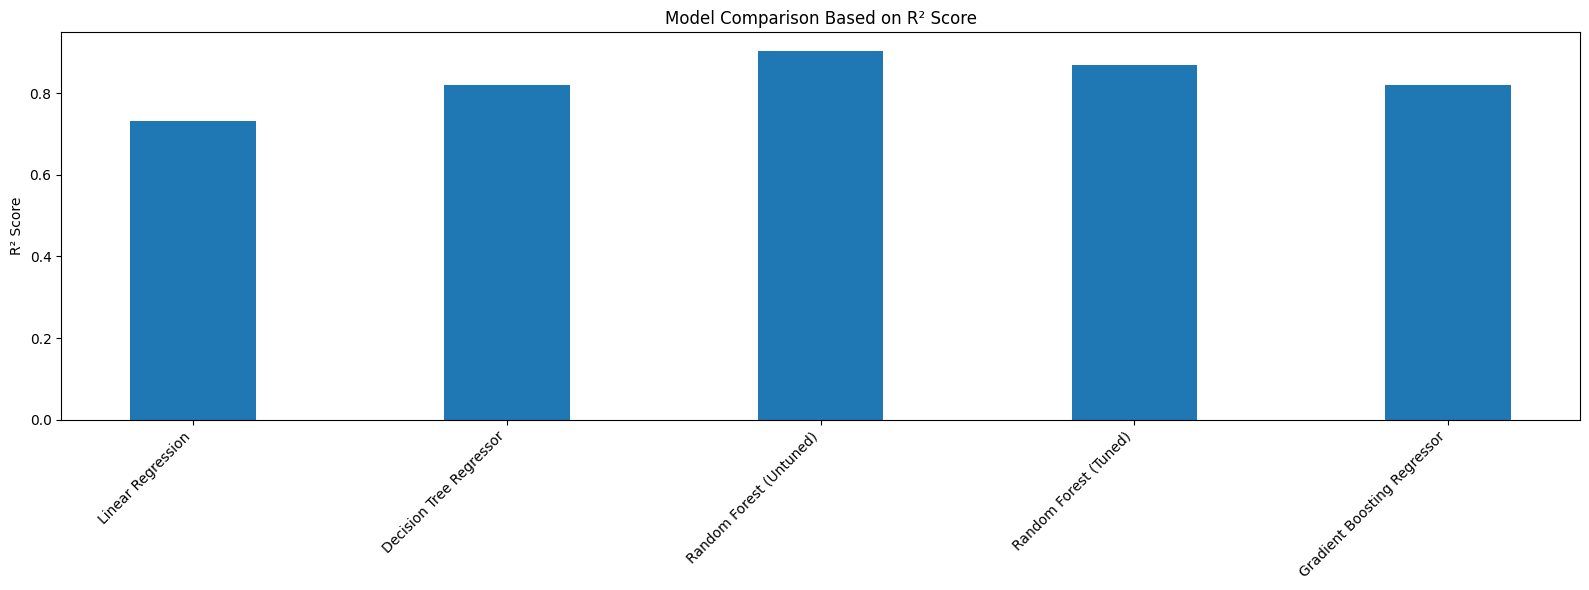

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
plt.bar(final_model_summary['Model'], final_model_summary['R2_Score'],width=0.4)
plt.xticks(rotation=45, ha='right')
plt.ylabel('R² Score')
plt.title('Model Comparison Based on R² Score')
plt.tight_layout()
plt.show()


### **Final Verdict**

   * The consolidated model comparison table summarizes the performance of all evaluated
regression models. 
   * The Random Forest (untuned) model achieves the highest R² score and
the lowest error metrics, indicating superior predictive accuracy. 
   * While hyperparameter tuning and Gradient Boosting were explored to improve robustness and reduce bias, they
     did not outperform the default Random Forest configuration.
   * The bar chart illustrates that the Random forest un-tuned has achieved high predictive accuracy over other models. hence,


* #### ***The Random Forest model(Untuned) is selected as the final production-ready model.***


### **Challenges Faced**

1. **Handling Categorical Variables**  
   The dataset contained multiple high-cardinality categorical features such as airline,
   route, and additional information. This was addressed using one-hot encoding to avoid
   introducing artificial ordinal relationships.

2. **Complex Feature Formats**  
   Features like journey date, departure time, arrival time, and duration were provided in
   textual or datetime formats. These were transformed into meaningful numerical features
   through systematic feature engineering.

3. **Model Overfitting Risk**  
   Tree-based models showed potential overfitting tendencies. This was mitigated by
   evaluating models using cross-validation and exploring hyperparameter tuning to balance
   bias and variance.

4. **High Dimensionality after Encoding**  
   One-hot encoding significantly increased the number of features. Ensemble models such
   as Random Forest handled this effectively without requiring aggressive feature reduction.

---------------------------------------------------------------------------------------------------------------------------------



### **Future Scope and Improvements:**

1. Incorporating real-time flight pricing data and seasonal demand indicators could further
   improve prediction accuracy.
2. Time-based train-test splitting can be explored to better simulate real-world price
   forecasting scenarios.
3. Advanced boosting techniques such as XGBoost or LightGBM may be evaluated for
   additional performance gains.  
    - Advanced gradient boosting frameworks such as XGBoost or LightGBM were not included in the  
    current implementation to maintain reproducibility and focus on core ensemble learning principles.
4. Feature selection techniques could be applied to reduce dimensionality and improve
   computational efficiency.
5. Deployment of the model as a web application or API could enable real-time flight fare
   prediction for end users.

   -------------------------------------------------------------------------------------------------------------------------------
